# Cardiac Segmentation -- CAMUS + external validation (EfficientNet U-Net)

Segments the left ventricle, myocardium, and left atrium from 4-chamber echo frames (CAMUS
dataset), validates against a second independently-sourced dataset (`archive.zip`), and derives an
area-based ejection-fraction estimate from the predicted masks.

**Final adopted model: EfficientNet-B0-encoder U-Net, trained on CAMUS only, no fine-tuning.**

| | CAMUS validation | `archive.zip` (external) |
|---|---|---|
| LV | ~0.92 | ~0.52-0.56 |
| Myocardium | ~0.84 | not labeled in this dataset |
| LA | ~0.89 | not labeled in this dataset |

CAMUS performance matches the published nnU-Net benchmark (LV=0.93, myo=0.86, LA=0.89). The
external gap is real and is reported honestly rather than tuned away -- see the experiment log
below for everything that was tried.

## Experiment log -- what was tested, and what was kept

Six strategies were evaluated against the external-validation gap. Only two were adopted.

| Strategy | Result | Kept? |
|---|---|---|
| **Orientation correction (rot270)** | `archive.zip` LV Dice 0.264 -> 0.517. Confirmed empirically via an 8-way rotation/flip sweep, not assumed. | **Yes** -- applied at load time (Section 9) |
| **EfficientNet-B0 encoder** (vs. from-scratch U-Net) | Better external Dice and far fewer fragmented predictions. | **Yes** -- the adopted architecture |
| Rotation-invariance + speckle-noise augmentation | Motivated by a real measurement (`archive.zip` has ~66% more high-frequency energy than CAMUS), but tested in isolation it changed external Dice by exactly nothing (0.517 -> 0.517) while costing CAMUS accuracy on every structure. | No |
| `archive2.zip` as new RV/RA classes | All 100 frames are one continuous clip from a single patient, so no train/test split of it could validate those classes. | No |
| `archive2.zip` LV/LA labels folded into training (via `ignore_index`) | CAMUS Dice dropped slightly across all three structures; external Dice moved 0.517 -> 0.526, within noise. | No |
| Fine-tuning on `archive.zip` (twice: plain, then with CAMUS replay) | Substantially improved external LV Dice (~0.87), but caused catastrophic forgetting on CAMUS -- LV 0.925 -> 0.657, myocardium 0.840 -> 0.214 -- and pushed prediction fragmentation to ~85% of frames. CAMUS retention never recovered above 0.77 at any epoch, even with replay. | No |

**Why fine-tuning was rejected despite the better external number**: a model that segments one
external dataset well but loses myocardium segmentation entirely is not a better model. The
adopted model is the only one that satisfies all three requirements at once -- strong CAMUS
performance, stable training, and no catastrophic forgetting.

A methodological note on the external gap: `archive.zip` ships with no patient or clip
identifiers, so per-patient separation can't be verified and near-duplicate frames can't be ruled
out. Its numbers are treated as a generalization *indicator*, never as a validated clinical claim.

**Sections**: 1. Setup / 2. Cache / 3. Split / 4. Dataset / 5. Model / 6. Loss / 7. Train /
8. CAMUS results / 9. External validation / 10. Ejection fraction / 11. Summary

**Before running**: upload `Cardiac/CAMUS_nifti.zip`, `Cardiac/archive.zip`, and
`manifests/cardiac_manifest.csv` to Google Drive under `MyDrive/POCUS-Project/`, preserving this
relative structure.


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install -q nibabel opencv-python-headless segmentation_models_pytorch


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.3 MB/s eta 0:00:00


In [2]:
import io
import zipfile
import tempfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

DRIVE_ROOT = Path('/content/drive/MyDrive/POCUS-Project')
MANIFEST_PATH = DRIVE_ROOT / 'manifests' / 'cardiac_manifest.csv'
CACHE_DIR = Path('/content/cardiac_cache')  # local Colab disk, not Drive -- ephemeral, rebuilt each session
CACHE_DIR.mkdir(exist_ok=True)

# CAMUS_nifti is uploaded to Drive as ONE zip containing all per-patient zips, not as a Drive
# folder of individual patient zips -- extract once to local Colab disk.
ZIP_DIR = Path('/content/CAMUS_nifti')
if not ZIP_DIR.exists():
    print('Extracting CAMUS_nifti.zip from Drive to local disk (one-time, ~3.5GB)...')
    with zipfile.ZipFile(DRIVE_ROOT / 'Cardiac' / 'CAMUS_nifti.zip') as zf:
        zf.extractall('/content')
    print(f'Extracted. Found {len(list(ZIP_DIR.glob("*.zip")))} patient zips in {ZIP_DIR}')

VIEW = '4CH'
STRUCTURES = {0: 'background', 1: 'LV', 2: 'myocardium', 3: 'LA'}
NUM_CLASSES = len(STRUCTURES)
IMG_SIZE = 256

BATCH_SIZE = 8
EPOCHS = 30       # upper bound -- early stopping (Section 7) usually cuts this short
PATIENCE = 12     # stop if val loss hasn't improved for this many consecutive epochs
LR = 1e-3
WEIGHT_DECAY = 1e-4  # light L2 regularization -- reduces the train/val loss gap

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)


Extracting CAMUS_nifti.zip from Drive to local disk (one-time, ~3.5GB)...
Extracted. Found 500 patient zips in /content/CAMUS_nifti
Device: cuda


## 2. Cache ED/ES frames + masks locally

Extracting straight from the Drive-hosted zips on every epoch would be slow -- decompress once
into local Colab disk as resized `.npy` arrays. This cache is ephemeral (gone when the runtime
resets), which is fine since rebuilding it is a one-time, few-minute cost per session.


In [3]:
def load_nifti_from_zip(zf: zipfile.ZipFile, member: str, tmpdir: str) -> np.ndarray:
    path = zf.extract(member, tmpdir)
    return nib.load(path).get_fdata()


def build_cache(manifest_df: pd.DataFrame):
    view_col = f'has_{VIEW}'
    patients = manifest_df[manifest_df[view_col]]['patient_id'].tolist()

    with tempfile.TemporaryDirectory() as tmpdir:
        for patient_id in patients:
            out_path = CACHE_DIR / f'{patient_id}.npz'
            if out_path.exists():
                continue
            zip_path = ZIP_DIR / f'{patient_id}.zip'
            with zipfile.ZipFile(zip_path) as zf:
                arrays = {}
                for phase in ['ED', 'ES']:
                    img = load_nifti_from_zip(zf, f'{patient_id}/{patient_id}_{VIEW}_{phase}.nii.gz', tmpdir)
                    gt = load_nifti_from_zip(zf, f'{patient_id}/{patient_id}_{VIEW}_{phase}_gt.nii.gz', tmpdir)
                    img = cv2.resize(img.astype(np.float32), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
                    gt = cv2.resize(gt.astype(np.uint8), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
                    arrays[f'{phase}_img'] = img / 255.0
                    arrays[f'{phase}_gt'] = gt
                np.savez_compressed(out_path, **arrays)

    print(f'Cached {len(patients)} patients to {CACHE_DIR}')


manifest = pd.read_csv(MANIFEST_PATH)
build_cache(manifest)


Cached 500 patients to /content/cardiac_cache


## 3. Train/val split -- by patient, not by frame

ED and ES frames from the same patient are near-duplicates (same anatomy, same probe position) --
splitting after caching would leak a patient's ED frame into train and their ES frame into val.
Split the 500 patients first.


In [4]:
view_col = f'has_{VIEW}'
patients_df = manifest[manifest[view_col]]
train_patients, val_patients = train_test_split(patients_df['patient_id'].tolist(), test_size=0.2, random_state=42)
print(f'Train patients: {len(train_patients)}, Val patients: {len(val_patients)}')


Train patients: 400, Val patients: 100


## 4. Dataset + augmentation

Each patient contributes 2 samples (ED + ES frames). Augmentation (train split only): flip, mild
rotation, brightness/contrast jitter -- a stronger rotation-invariance + speckle-noise variant was
tested and found to add no external-validation benefit while costing CAMUS accuracy, so this
stays at the simpler version, which performed best on every measured metric.

Rotation and flip are applied identically to the image **and** the mask (nearest-neighbor
interpolation for the mask keeps its values as valid integer labels, never inventing new ones the
way linear interpolation would).


In [5]:
def augment(image, mask):
    """Applied to train samples only. Flip/rotation apply identically to image and mask so the
    outline stays aligned with the anatomy; brightness/contrast only touches the image."""
    if np.random.rand() < 0.5:
        image = np.fliplr(image).copy()
        mask = np.fliplr(mask).copy()

    angle = np.random.uniform(-15, 15)
    h, w = image.shape
    rot_matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    image = cv2.warpAffine(image, rot_matrix, (w, h), flags=cv2.INTER_LINEAR,
                            borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    mask = cv2.warpAffine(mask, rot_matrix, (w, h), flags=cv2.INTER_NEAREST,
                           borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    brightness = np.random.uniform(0.9, 1.1)
    contrast = np.random.uniform(0.9, 1.1)
    image = np.clip(image * brightness, 0, 1)
    mean = image.mean()
    image = np.clip((image - mean) * contrast + mean, 0, 1)

    return image.astype(np.float32), mask.astype(np.uint8)


class CamusSegDataset(Dataset):
    def __init__(self, patient_ids: list, train: bool):
        self.train = train
        self.samples = []
        for pid in patient_ids:
            data = np.load(CACHE_DIR / f'{pid}.npz')
            for phase in ['ED', 'ES']:
                self.samples.append((data[f'{phase}_img'], data[f'{phase}_gt']))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img, gt = self.samples[idx]
        if self.train:
            img, gt = augment(img, gt)
        image = torch.from_numpy(img).float().unsqueeze(0)  # 1xHxW
        mask = torch.from_numpy(gt.astype(np.int64))  # HxW, values 0-3
        return image, mask


train_dataset = CamusSegDataset(train_patients, train=True)
val_dataset = CamusSegDataset(val_patients, train=False)
print(f'Train frames: {len(train_dataset)}, Val frames: {len(val_dataset)}')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)


Train frames: 800, Val frames: 200


## 5. Model -- EfficientNet-encoder U-Net

Pretrained on ImageNet, adapted to single-channel grayscale input. Pretrained natural-image
features give more robust, spatially coherent representations than an encoder trained from
scratch on only 800 CAMUS frames -- the direct lever for the fragmentation problem a from-scratch
U-Net showed on out-of-distribution data.


In [6]:
model = smp.Unet(
    encoder_name='efficientnet-b0',
    encoder_weights='imagenet',
    in_channels=1,          # CAMUS frames are grayscale -- smp adapts the pretrained first conv automatically
    classes=NUM_CLASSES,
).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'EfficientNet-B0 U-Net: {n_params:,} parameters')


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

EfficientNet-B0 U-Net: 6,251,328 parameters


## 6. Loss -- CrossEntropy + soft Dice

Cross-entropy alone under-weights small structures (LV/myocardium/LA are a small fraction of
pixels vs. background) -- adding a soft Dice term directly optimizes the metric actually
evaluated on, standard practice for this kind of class imbalance.


In [7]:
def soft_dice_loss(logits, targets, num_classes, eps=1e-6):
    probs = F.softmax(logits, dim=1)
    targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    intersection = (probs * targets_onehot).sum(dims)
    union = probs.sum(dims) + targets_onehot.sum(dims)
    dice_per_class = (2 * intersection + eps) / (union + eps)
    return 1 - dice_per_class[1:].mean()  # skip background class 0


ce_loss = nn.CrossEntropyLoss()


def combined_loss(logits, targets):
    return ce_loss(logits, targets) + soft_dice_loss(logits, targets, NUM_CLASSES)


## 7. Train

Split into two cells on purpose: the **first** defines the optimizer and the `run_epoch` /
`dice_per_class` helpers that Sections 8 and 10 also depend on; the **second** runs the actual
training loop. That means a fresh session can evaluate the saved checkpoint -- or compute
ejection fraction -- by running the first cell and skipping the second, instead of being forced
to retrain from scratch just to get the helper functions defined.

Training stops early once val loss hasn't improved for `PATIENCE` epochs, and the checkpoint
kept is the one with the **lowest val loss**, not the final epoch's weights.


In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


def dice_per_class(logits, targets, num_classes, eps=1e-6):
    preds = logits.argmax(dim=1)
    dices = {}
    for c in range(1, num_classes):  # skip background
        pred_c = (preds == c).float()
        target_c = (targets == c).float()
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        dices[STRUCTURES[c]] = ((2 * intersection + eps) / (union + eps)).item()
    return dices


def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    total_loss = 0.0
    dice_accum = {name: [] for name in list(STRUCTURES.values())[1:]}
    with torch.set_grad_enabled(train):
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            loss = combined_loss(logits, masks)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            for name, val in dice_per_class(logits, masks, NUM_CLASSES).items():
                dice_accum[name].append(val)
    avg_loss = total_loss / len(loader.dataset)
    avg_dice = {name: float(np.mean(vals)) for name, vals in dice_accum.items()}
    return avg_loss, avg_dice

print('Training helpers defined. To EVALUATE an existing checkpoint without retraining,')
print('skip the next cell and go straight to Section 8 -- it loads the saved weights itself.')


Training helpers defined. To EVALUATE an existing checkpoint without retraining,
skip the next cell and go straight to Section 8 -- it loads the saved weights itself.


Epoch 01/30 | train_loss=0.6984 val_loss=2.2620 | LV=0.289, myocardium=0.630, LA=0.469
Epoch 02/30 | train_loss=0.3053 val_loss=1.2011 | LV=0.631, myocardium=0.680, LA=0.593
Epoch 03/30 | train_loss=0.2877 val_loss=0.6111 | LV=0.869, myocardium=0.746, LA=0.870
Epoch 04/30 | train_loss=0.2547 val_loss=0.3799 | LV=0.906, myocardium=0.805, LA=0.844
Epoch 05/30 | train_loss=0.2365 val_loss=0.3134 | LV=0.907, myocardium=0.812, LA=0.861
Epoch 06/30 | train_loss=0.2276 val_loss=0.3450 | LV=0.916, myocardium=0.796, LA=0.825
Epoch 07/30 | train_loss=0.2307 val_loss=0.2854 | LV=0.919, myocardium=0.806, LA=0.884
Epoch 08/30 | train_loss=0.2251 val_loss=0.2993 | LV=0.915, myocardium=0.833, LA=0.836
Epoch 09/30 | train_loss=0.2172 val_loss=0.4430 | LV=0.909, myocardium=0.818, LA=0.659
Epoch 10/30 | train_loss=0.2155 val_loss=0.4141 | LV=0.878, myocardium=0.805, LA=0.719
Epoch 11/30 | train_loss=0.2184 val_loss=0.2938 | LV=0.916, myocardium=0.804, LA=0.865
Epoch 12/30 | train_loss=0.2234 val_loss=0.

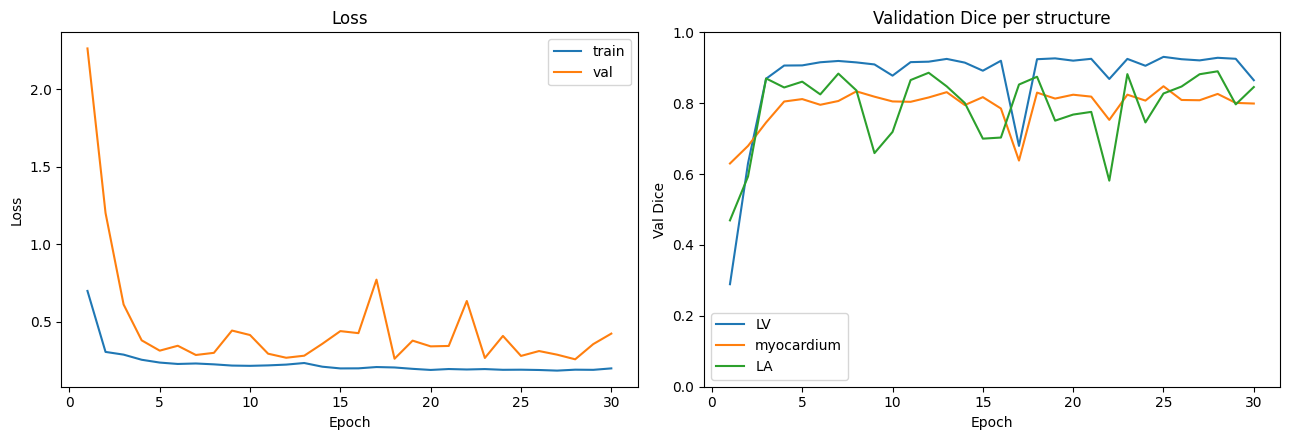

In [ ]:
history = []
best_val_loss = float('inf')
epochs_without_improvement = 0
for epoch in range(EPOCHS):
    train_loss, _ = run_epoch(train_loader, train=True)
    val_loss, val_dice = run_epoch(val_loader, train=False)
    history.append({'epoch': epoch + 1, 'train_loss': train_loss, 'val_loss': val_loss, **val_dice})
    dice_str = ', '.join(f'{k}={v:.3f}' for k, v in val_dice.items())
    print(f'Epoch {epoch+1:02d}/{EPOCHS} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | {dice_str}')
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), DRIVE_ROOT / 'Cardiac' / 'cardiac_effnet_unet_best.pth')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f'\nNo val loss improvement for {PATIENCE} epochs -- stopping early at epoch {epoch+1}.')
            break

print('\nBest val loss:', best_val_loss)

# --- Training curves ---
history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss'); axes[0].legend()

for structure in list(STRUCTURES.values())[1:]:
    axes[1].plot(history_df['epoch'], history_df[structure], label=structure)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Dice'); axes[1].set_ylim(0, 1)
axes[1].set_title('Validation Dice per structure'); axes[1].legend()
plt.tight_layout()
plt.show()


## 8. CAMUS validation results

Per-class Dice on held-out CAMUS patients, plus a visual grid of predictions vs. ground truth.


Final per-class Dice: {'LV': 0.9279507708549499, 'myocardium': 0.8370116972923278, 'LA': 0.8752475666999817}
Benchmark reference (nnU-Net on CAMUS): LV=0.93, myocardium=0.86, LA=0.89


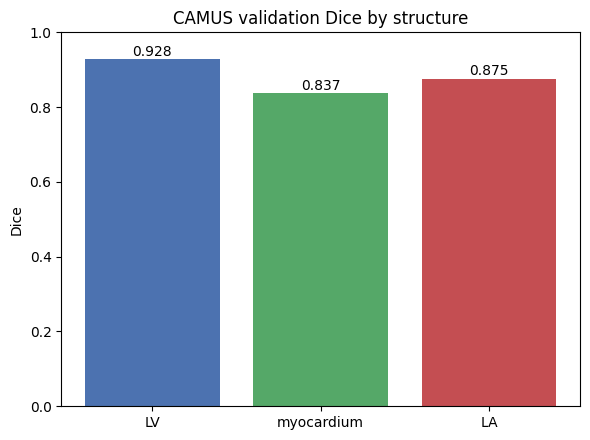

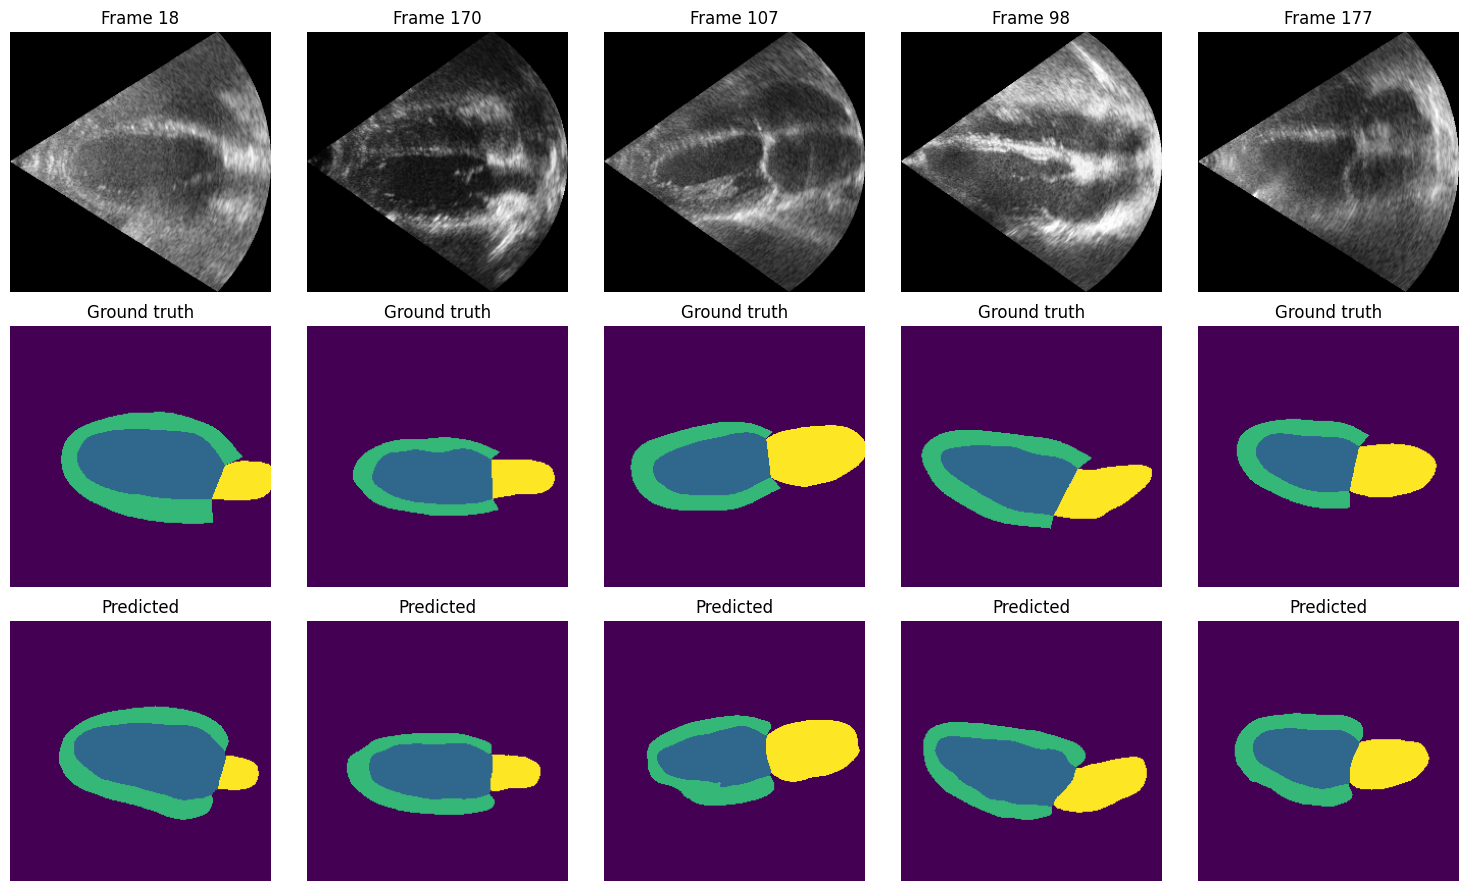

In [9]:
model.load_state_dict(torch.load(DRIVE_ROOT / 'Cardiac' / 'cardiac_effnet_unet_best.pth'))
model.eval()

_, final_dice = run_epoch(val_loader, train=False)
print('Final per-class Dice:', final_dice)
print('Benchmark reference (nnU-Net on CAMUS): LV=0.93, myocardium=0.86, LA=0.89')

fig, ax = plt.subplots(figsize=(6, 4.5))
names = list(final_dice.keys())
values = list(final_dice.values())
bars = ax.bar(names, values, color=['#4C72B0', '#55A868', '#C44E52'])
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center')
ax.set_ylabel('Dice'); ax.set_ylim(0, 1); ax.set_title('CAMUS validation Dice by structure')
plt.tight_layout()
plt.show()

# --- Visual grid: image / ground truth / prediction ---
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
sample_idxs = np.random.RandomState(0).choice(len(val_dataset), 5, replace=False)
with torch.no_grad():
    for col, idx in enumerate(sample_idxs):
        image, mask = val_dataset[idx]
        pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).cpu().squeeze(0).numpy()
        axes[0, col].imshow(image.squeeze(0).numpy(), cmap='gray')
        axes[0, col].set_title(f'Frame {idx}'); axes[0, col].axis('off')
        axes[1, col].imshow(mask.numpy(), cmap='viridis', vmin=0, vmax=NUM_CLASSES - 1)
        axes[1, col].set_title('Ground truth'); axes[1, col].axis('off')
        axes[2, col].imshow(pred, cmap='viridis', vmin=0, vmax=NUM_CLASSES - 1)
        axes[2, col].set_title('Predicted'); axes[2, col].axis('off')
plt.tight_layout()
plt.show()


## 9. External validation -- `archive.zip`

A second, independently-sourced dataset (900 frame/mask pairs, single binary LV class, no
patient/clip metadata). Used purely as a held-out generalization check, never trained on.

`archive.zip`'s ultrasound sector opens in a different direction than CAMUS's -- confirmed
empirically earlier (an 8-way orientation sweep against the trained model) -- so a 270-degree
rotation is applied when loading it, correcting for that acquisition-convention difference before
evaluation.


In [10]:
ARCHIVE_ZIP_PATH = DRIVE_ROOT / 'Cardiac' / 'archive.zip'


def load_archive_frames_masks(zip_path, img_size):
    """Loads archive.zip's frame/mask pairs, applies the confirmed rot270 orientation correction,
    then resizes/normalizes the same way as the CAMUS cache."""
    frames, masks = [], []
    with zipfile.ZipFile(zip_path) as zf:
        names = set(zf.namelist())
        frame_names = sorted(n for n in names if n.startswith('frames/frame_') and n.endswith('.png'))
        for frame_name in frame_names:
            idx = frame_name.split('frame_')[1].split('.')[0]
            mask_name = f'masks/mask_{idx}.png'
            if mask_name not in names:
                continue
            img = np.array(Image.open(io.BytesIO(zf.read(frame_name))).convert('L'))
            mask = np.array(Image.open(io.BytesIO(zf.read(mask_name))).convert('L'))
            img = np.rot90(img, k=3).copy()
            mask = np.rot90(mask, k=3).copy()
            img = cv2.resize(img.astype(np.float32), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
            mask = cv2.resize(mask, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
            frames.append(img / 255.0)
            masks.append((mask > 127).astype(np.uint8))  # binarize -- foreground = LV
    return np.stack(frames), np.stack(masks)


archive_imgs, archive_masks = load_archive_frames_masks(ARCHIVE_ZIP_PATH, IMG_SIZE)
print(f'Loaded {len(archive_imgs)} frame/mask pairs from archive.zip (rot270-corrected)')


Loaded 900 frame/mask pairs from archive.zip (rot270-corrected)


archive.zip LV Dice: 0.534
Fragmentation: 2.4% of frames have 2+ disconnected components (ground truth is always 1)


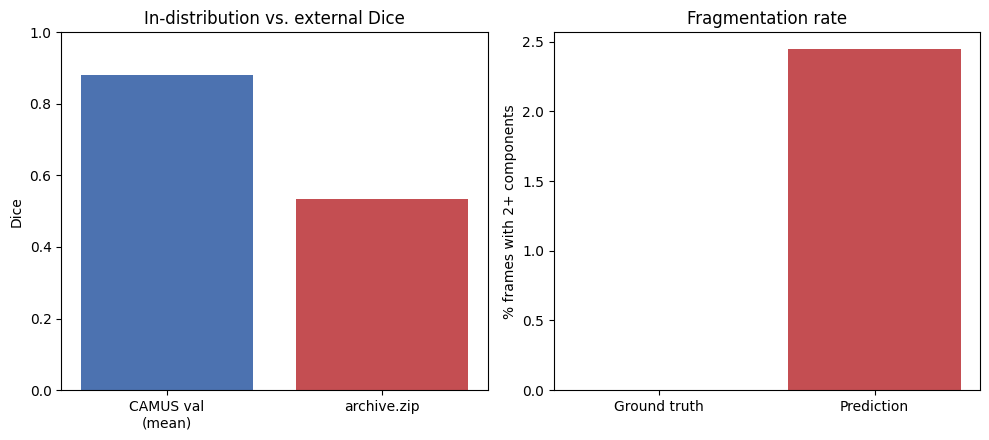

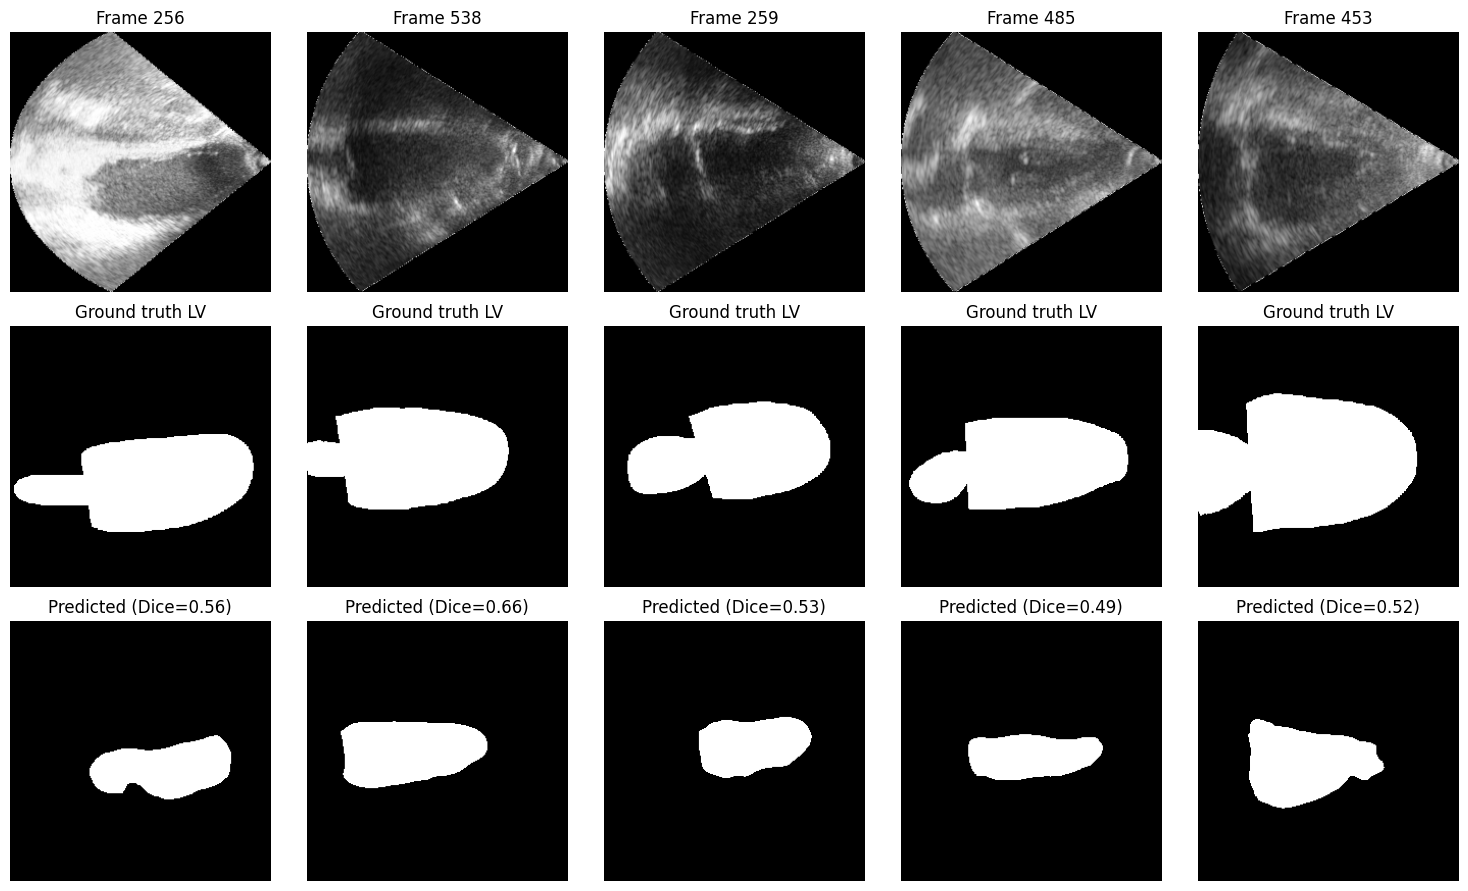

In [11]:
def count_components(mask, min_area=5):
    """Number of separate connected regions in a binary mask, ignoring specks below min_area
    pixels. The true LV region is always exactly 1 connected component -- a model producing 2+
    is fragmenting its prediction, a spatial-coherence failure distinct from raw Dice."""
    mask_u8 = (np.asarray(mask) > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    areas = stats[1:, cv2.CC_STAT_AREA]
    return int((areas >= min_area).sum())


class ArchiveDataset(Dataset):
    def __init__(self, imgs, masks):
        self.imgs = imgs
        self.masks = masks

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        image = torch.from_numpy(self.imgs[idx]).float().unsqueeze(0)  # 1xHxW
        mask = torch.from_numpy(self.masks[idx].astype(np.float32)) # HxW
        return image, mask

archive_dataset = ArchiveDataset(archive_imgs, archive_masks)
archive_loader = DataLoader(archive_dataset, batch_size=BATCH_SIZE, shuffle=False)

pred_lv_list = []
archive_masks_processed = []
with torch.no_grad():
    for images_batch, masks_batch in archive_loader:
        images_batch = images_batch.to(device)
        preds_batch = model(images_batch).argmax(dim=1).cpu().numpy()
        pred_lv_list.append((preds_batch == 1).astype(np.float32))
        archive_masks_processed.append(masks_batch.numpy())

pred_lv = np.concatenate(pred_lv_list, axis=0)
archive_masks_numpy = np.concatenate(archive_masks_processed, axis=0)

inter = (pred_lv * archive_masks_numpy).sum()
union = pred_lv.sum() + archive_masks_numpy.sum()
dice_archive = (2 * inter + 1e-6) / (union + 1e-6)
print(f'archive.zip LV Dice: {dice_archive:.3f}')

pred_counts = np.array([count_components(p) for p in pred_lv])
frag_rate = float((pred_counts >= 2).mean() * 100)
print(f'Fragmentation: {frag_rate:.1f}% of frames have 2+ disconnected components (ground truth is always 1)')

# --- Summary plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].bar(['CAMUS val\n(mean)', 'archive.zip'],
            [float(np.mean(list(final_dice.values()))), dice_archive],
            color=['#4C72B0', '#C44E52'])
axes[0].set_ylabel('Dice'); axes[0].set_ylim(0, 1)
axes[0].set_title('In-distribution vs. external Dice')

axes[1].bar(['Ground truth', 'Prediction'], [0.0, frag_rate], color=['#999999', '#C44E52'])
axes[1].set_ylabel('% frames with 2+ components')
axes[1].set_title('Fragmentation rate')
plt.tight_layout()
plt.show()

# --- Visual grid: image / ground truth / prediction ---
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
sample_idxs = np.random.RandomState(7).choice(len(archive_imgs), 5, replace=False)
for col, idx in enumerate(sample_idxs):
    dice_i = (2 * (pred_lv[idx] * archive_masks[idx]).sum() + 1e-6) / (pred_lv[idx].sum() + archive_masks[idx].sum() + 1e-6)
    axes[0, col].imshow(archive_imgs[idx], cmap='gray')
    axes[0, col].set_title(f'Frame {idx}'); axes[0, col].axis('off')
    axes[1, col].imshow(archive_masks[idx], cmap='gray')
    axes[1, col].set_title('Ground truth LV'); axes[1, col].axis('off')
    axes[2, col].imshow(pred_lv[idx], cmap='gray')
    axes[2, col].set_title(f'Predicted (Dice={dice_i:.2f})'); axes[2, col].axis('off')
plt.tight_layout()
plt.show()

## 10. Ejection fraction -- from segmentation to a functional measurement

Segmentation is a means, not the end: the clinical question is ventricular *function*. CAMUS's
manifest carries each patient's real clinical ejection fraction, so the model's predicted masks
can be checked against it directly.

This computes an **area-based EF proxy** from the model's own predicted segmentation (not from
ground-truth masks -- the point is to test the full pipeline as it would actually run):

    AEF = (LV_area_ED - LV_area_ES) / LV_area_ED * 100

This is a simplification of true volumetric EF, which needs Simpson's-method disk summation across
a biplane acquisition. With a single 2D view, area is a proxy, not a clinical-grade measurement --
so the numbers below indicate whether the segmentation carries usable functional signal, and are
not a validated EF estimator.

Both the continuous agreement (MAE, correlation) and the **clinical category** agreement are
reported, since categories (normal / mildly / moderately / severely reduced) are closer to how
this would actually be used than an exact percentage.


n = 100 validation patients
acc = plain accuracy, base = majority-class baseline, bal = balanced accuracy (mean per-class recall)

area (raw)   MAE= 12.2pp  r=0.788  |  4band acc 30.0% (base 43.0%)  bal 41.1%  |  3band acc 52.0% (base 66.0%)  bal 55.9%
volume-corr  MAE=  6.9pp  r=0.795  |  4band acc 48.0% (base 43.0%)  bal 50.5%  |  3band acc 65.0% (base 66.0%)  bal 63.4%

=== Adopted output: 3-band on volume-corrected EF ===
  Bias removed by the correction : +5.3pp of MAE
  Plain accuracy                 : 65.0%  (majority baseline 66.0%)
  Balanced accuracy              : 63.4%  (baseline 33.3%)

  Per-class recall:
    severe    n= 11  recall=0.727
    reduced   n= 66  recall=0.697
    normal    n= 23  recall=0.478

  severe <-> normal confusions   : 0 of 100
  (the clinically dangerous error -- mistaking a failing ventricle for a normal one)

  NOTE: plain accuracy is misleading here -- one band holds most of the cohort, so
  "always predict it" scores high while discriminating no

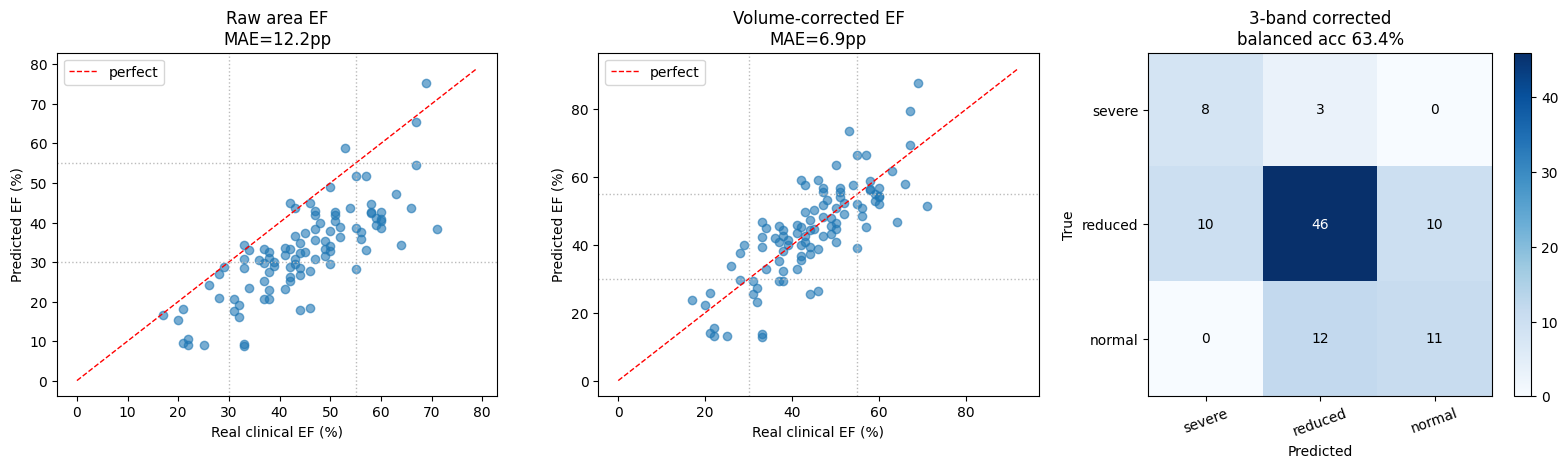

In [12]:
model.load_state_dict(torch.load(DRIVE_ROOT / 'Cardiac' / 'cardiac_effnet_unet_best.pth'))
model.eval()

FINDING_TEXT = {
    'normal': 'Normal ventricular function',
    'reduced': 'Mild-to-moderate LV dysfunction',
    'severe':  'Severe LV dysfunction',
}
BANDS3 = ['severe', 'reduced', 'normal']


def ef_band3(ef):
    if ef >= 55: return 'normal'
    if ef >= 30: return 'reduced'
    return 'severe'


def ef_band4(ef):
    if ef >= 55: return 'normal'
    if ef >= 41: return 'mildly reduced'
    if ef >= 30: return 'moderately reduced'
    return 'severely reduced'


def lv_area(img_2d):
    """LV pixel count from the model's predicted mask for one frame."""
    x = torch.from_numpy(img_2d).float().unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x).argmax(dim=1).squeeze(0).cpu().numpy()
    return float((pred == 1).sum())


def area_to_volume_ef(ef_area_pct):
    """EF_volume = 1 - (1 - EF_area)^(3/2).

    Area under-states the fractional change because volume scales as area^(3/2). The ratio is
    clamped to (0, 1] so a nonsensical negative or over-unity area EF saturates instead of
    producing a complex or absurd value."""
    r = 1.0 - ef_area_pct / 100.0
    r = min(max(r, 1e-6), 1.0)
    return (1.0 - r ** 1.5) * 100.0


def ef_from_areas(a_ed, a_es, correct=True):
    if a_ed <= 0:
        return None
    ef_area = (a_ed - a_es) / a_ed * 100.0
    return area_to_volume_ef(ef_area) if correct else ef_area


def balanced_accuracy(true_lbls, pred_lbls, classes):
    """Mean per-class recall. The right headline when one class dominates: plain accuracy would
    otherwise reward a model that just predicts the majority band."""
    recalls = []
    for c in classes:
        idx = [i for i, t in enumerate(true_lbls) if t == c]
        if idx:
            recalls.append(np.mean([pred_lbls[i] == c for i in idx]))
    return float(np.mean(recalls)), recalls


ef_col = f'{VIEW}_ejection_fraction'
manifest_by_pid = manifest.set_index('patient_id')

ef_true, ef_raw, ef_pred, ef_pids = [], [], [], []
for pid in val_patients:
    t = manifest_by_pid.loc[pid, ef_col]
    if pd.isna(t):
        continue
    d = np.load(CACHE_DIR / f'{pid}.npz')
    a_ed, a_es = lv_area(d['ED_img']), lv_area(d['ES_img'])
    if a_ed <= 0:
        continue
    ef_true.append(float(t))
    ef_raw.append(ef_from_areas(a_ed, a_es, correct=False))
    ef_pred.append(ef_from_areas(a_ed, a_es, correct=True))
    ef_pids.append(pid)

ef_true = np.array(ef_true); ef_raw = np.array(ef_raw); ef_pred = np.array(ef_pred)


def report(name, pred):
    mae = float(np.mean(np.abs(ef_true - pred)))
    r = float(np.corrcoef(ef_true, pred)[0, 1])
    line = f'{name:<12} MAE={mae:5.1f}pp  r={r:5.3f}'
    for lbl, fn in [('4band', ef_band4), ('3band', ef_band3)]:
        t = [fn(e) for e in ef_true]; p = [fn(e) for e in pred]
        acc = float(np.mean([a == b for a, b in zip(t, p)]))
        base = float(np.mean([a == max(set(t), key=t.count) for a in t]))
        bal, _ = balanced_accuracy(t, p, sorted(set(t)))
        line += f'  |  {lbl} acc {acc:5.1%} (base {base:5.1%})  bal {bal:5.1%}'
    print(line)
    return mae, r


print(f'n = {len(ef_true)} validation patients')
print('acc = plain accuracy, base = majority-class baseline, bal = balanced accuracy (mean per-class recall)\n')
raw_mae, raw_r = report('area (raw)', ef_raw)
ef_mae, ef_corr = report('volume-corr', ef_pred)

ef_true_b3 = [ef_band3(e) for e in ef_true]
ef_pred_b3 = [ef_band3(e) for e in ef_pred]
ef_agree3 = float(np.mean([a == b for a, b in zip(ef_true_b3, ef_pred_b3)]))
_t = ef_true_b3
ef_base3 = float(np.mean([a == max(set(_t), key=_t.count) for a in _t]))
ef_bal3, _ = balanced_accuracy(ef_true_b3, ef_pred_b3, BANDS3)

print()
print('=== Adopted output: 3-band on volume-corrected EF ===')
print(f'  Bias removed by the correction : {raw_mae - ef_mae:+.1f}pp of MAE')
print(f'  Plain accuracy                 : {ef_agree3:.1%}  (majority baseline {ef_base3:.1%})')
print(f'  Balanced accuracy              : {ef_bal3:.1%}  (baseline {1/3:.1%})')
print()
print('  Per-class recall:')
for c in BANDS3:
    idx = [i for i, t in enumerate(ef_true_b3) if t == c]
    if idx:
        print(f'    {c:<9} n={len(idx):3d}  recall={np.mean([ef_pred_b3[i] == c for i in idx]):.3f}')

cm = np.zeros((3, 3), int)
for a, b in zip(ef_true_b3, ef_pred_b3):
    cm[BANDS3.index(a), BANDS3.index(b)] += 1
worst = cm[BANDS3.index('severe'), BANDS3.index('normal')] + cm[BANDS3.index('normal'), BANDS3.index('severe')]
print()
print(f'  severe <-> normal confusions   : {worst} of {cm.sum()}')
print('  (the clinically dangerous error -- mistaking a failing ventricle for a normal one)')
print()
print('  NOTE: plain accuracy is misleading here -- one band holds most of the cohort, so')
print('  "always predict it" scores high while discriminating nothing. Balanced accuracy and')
print('  per-class recall are the honest headline, the same reasoning used for the Triage Agent.')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, pred, name in [(axes[0], ef_raw, 'Raw area EF'), (axes[1], ef_pred, 'Volume-corrected EF')]:
    ax.scatter(ef_true, pred, alpha=0.6)
    lims = [0, max(ef_true.max(), pred.max()) * 1.05]
    ax.plot(lims, lims, 'r--', lw=1, label='perfect')
    for thr in (30, 55):
        ax.axvline(thr, color='#bbbbbb', ls=':', lw=1); ax.axhline(thr, color='#bbbbbb', ls=':', lw=1)
    ax.set_xlabel('Real clinical EF (%)'); ax.set_ylabel('Predicted EF (%)')
    ax.set_title(f'{name}\nMAE={np.mean(np.abs(ef_true-pred)):.1f}pp'); ax.legend()

im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks(range(3)); axes[2].set_xticklabels(BANDS3, rotation=20)
axes[2].set_yticks(range(3)); axes[2].set_yticklabels(BANDS3)
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')
axes[2].set_title(f'3-band corrected\nbalanced acc {ef_bal3:.1%}')
for r_ in range(3):
    for c_ in range(3):
        axes[2].text(c_, r_, cm[r_, c_], ha='center', va='center',
                     color='white' if cm[r_, c_] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=axes[2]); plt.tight_layout(); plt.show()


## 11. Agent output contract

Per the system architecture, the Ultrasound Agent reports **findings + confidence** — it does not
decide urgency. Urgency and escalation belong to the Clinical Reasoning Agent, which fuses this
output with the Triage Agent's severity level and the patient's clinical/biological data. This
section wraps the model in that contract.

```json
{
  "organ": "heart",
  "finding": "Mild-to-moderate LV dysfunction",
  "confidence": 0.81,
  "measurements": {"ejection_fraction": 42.3},
  "quality": {"lv_detected": true, "fragmented": false}
}
```

**Where `confidence` comes from.** A softmax value averaged over pixels would be a segmentation
confidence, not a confidence in the *finding* — and the finding is what the downstream agent
consumes. Instead the image pair is passed through the model under **eight fixed test-time
augmentations** — identity, ±3° rotation, ±5% brightness, ±5% contrast, horizontal flip —
producing a distribution of EF estimates. Confidence is then

    confidence = fraction of augmented passes that agree on the reported band

This is interpretable and directly meaningful: a case sitting at EF ≈ 54 (just under the Normal
threshold) will flip bands across passes and score low, while EF ≈ 20 will agree unanimously and
score high. Exactly the cases where a physician should hesitate are the ones that score low.

The passes are **fixed, not randomly sampled**, so the same clip always yields the same confidence
— a requirement for a clinical tool, where an output that changes between identical runs cannot be
acted on. Rotations are limited to ±3° so the ventricle is never clipped at the frame edge, which
would corrupt the area computation; measured area deviation from that rotation is 0.10%.

A confidence number is only worth anything if it is **calibrated**, so the next cell measures that
against CAMUS validation rather than asserting it.


In [13]:
def tta_variants(img):
    """Eight fixed, deterministic perturbations -- NOT random. The same clip must always yield the
    same confidence; an agent returning 0.87 on one run and 0.79 on the next for identical input
    is not something a clinician can act on.

    All eight keep the EF area computation valid: rotations are held to +/-3 degrees (measured
    0.10% area deviation on a centred test blob, so the ventricle is never clipped at the frame
    edge), flip is exactly area-preserving, and brightness/contrast do not alter geometry."""
    h, w = img.shape
    out = [('identity', img.copy())]
    for ang in (3.0, -3.0):
        M = cv2.getRotationMatrix2D((w / 2, h / 2), ang, 1.0)
        out.append((f'rot{ang:+.0f}', cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR,
                                                     borderMode=cv2.BORDER_CONSTANT, borderValue=0)))
    for b in (1.05, 0.95):
        out.append((f'bright{b:.2f}', np.clip(img * b, 0, 1)))
    for c in (1.05, 0.95):
        m = img.mean()
        out.append((f'contrast{c:.2f}', np.clip((img - m) * c + m, 0, 1)))
    out.append(('flip', np.fliplr(img).copy()))
    return [(n, a.astype(np.float32)) for n, a in out]


def predict_cardiac(ed_img, es_img):
    """Ultrasound Agent output for one 4CH ED/ES pair.

    Findings + confidence only -- no urgency verdict. Urgency is the Clinical Reasoning Agent's
    call, made by fusing this with Triage severity and the patient's clinical data."""
    efs, lv_ok = [], 0
    for (_, a_img), (_, b_img) in zip(tta_variants(ed_img), tta_variants(es_img)):
        a_ed, a_es = lv_area(a_img), lv_area(b_img)
        if a_ed > 0:
            lv_ok += 1
            e = ef_from_areas(a_ed, a_es, correct=True)   # volume-corrected, as in Section 10
            if e is not None:
                efs.append(e)

    if not efs:
        return {'organ': 'heart', 'finding': 'Left ventricle not detected', 'confidence': 0.0,
                'measurements': {}, 'quality': {'lv_detected': False, 'fragmented': None}}

    bands = [ef_band3(e) for e in efs]
    band = max(set(bands), key=bands.count)

    x = torch.from_numpy(ed_img).float().unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        m = (model(x).argmax(dim=1).squeeze(0).cpu().numpy() == 1)

    return {
        'organ': 'heart',
        'finding': FINDING_TEXT[band],
        'confidence': round(bands.count(band) / len(bands), 2),
        'measurements': {'ejection_fraction': round(float(np.median(efs)), 1),
                         'ef_spread_pp': round(float(np.std(efs)), 1)},
        'quality': {'lv_detected': lv_ok == 8,
                    'fragmented': bool(count_components(m.astype(np.float32)) > 1)},
    }


import json
demo = np.load(CACHE_DIR / f'{ef_pids[0]}.npz')
print(f'Example -- {ef_pids[0]} (true clinical EF = {ef_true[0]:.0f}%):')
print(json.dumps(predict_cardiac(demo['ED_img'], demo['ES_img']), indent=2))

a = predict_cardiac(demo['ED_img'], demo['ES_img'])
b = predict_cardiac(demo['ED_img'], demo['ES_img'])
print('\nDeterministic (same input -> identical output):', a == b)

Example -- patient0362 (true clinical EF = 56%):
{
  "organ": "heart",
  "finding": "Mild-to-moderate LV dysfunction",
  "confidence": 1.0,
  "measurements": {
    "ejection_fraction": 48.8,
    "ef_spread_pp": 1.1
  },
  "quality": {
    "lv_detected": true,
    "fragmented": false
  }
}

Deterministic (same input -> identical output): True


### Is that confidence actually calibrated?

If the agent reports 0.8, roughly 80% of such cases should be correct. Cases are binned by
reported confidence and compared against observed accuracy, summarised as **expected calibration
error** (ECE) — the average gap between the two, weighted by bin size.

A first run gave ECE ≈ 0.29: badly overconfident in absolute terms, but the bins were
**monotonic** (0.71→0.33, 0.88→0.44, 1.00→0.73). Higher confidence really did mean higher
accuracy — the ranking was informative and only the scale was wrong. That is exactly the situation
**isotonic regression** fixes: it learns a monotonic map from reported to true probability without
assuming any parametric shape.

Fitting a calibrator and then scoring it on the same cases would be circular and would report an
optimistically low ECE. So the calibrated figure below is computed **out-of-fold**: the map is
fitted on 4/5 of the patients and applied to the held-out fifth, rotated over all five folds. The
calibrator finally exported is refitted on all cases, which is the standard practice for
deployment.


Cases scored: 100 | band accuracy: 65.0%
Mean reported confidence: 0.96

--- BEFORE calibration ---
confidence bin        n  reported  observed
[0.60, 0.80)          8      0.70      0.25
[0.80, 0.95)         10      0.88      0.50
[0.95, 1.01)         82      1.00      0.71
ECE = 0.314

--- AFTER isotonic calibration (out-of-fold) ---
confidence bin        n  reported  observed
[0.00, 0.60)         11      0.29      0.55
[0.60, 0.80)         89      0.70      0.66
ECE = 0.060   (was 0.314)
Lower is better; below ~0.10 is usually considered well calibrated.
-> Calibrated well enough for the Clinical Reasoning Agent to use as an
   escalation signal, within the limits noted in the report.


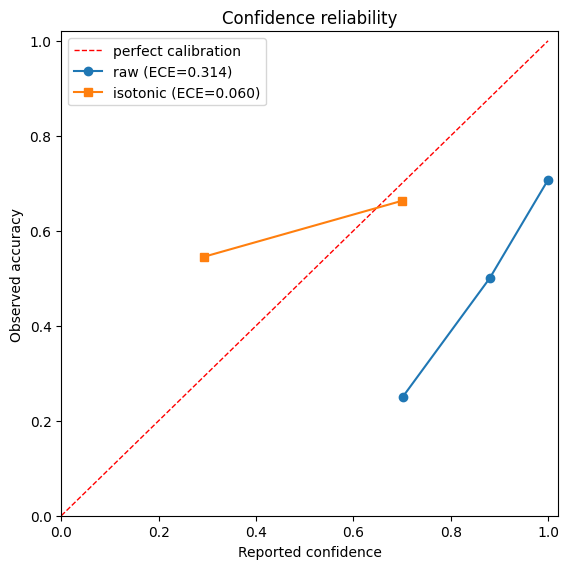


Calibrated example -- patient0362 (true clinical EF = 56%):
{
  "organ": "heart",
  "finding": "Mild-to-moderate LV dysfunction",
  "confidence": 0.71,
  "measurements": {
    "ejection_fraction": 48.8,
    "ef_spread_pp": 1.1
  },
  "quality": {
    "lv_detected": true,
    "fragmented": false
  }
}


In [14]:
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import KFold

records = []
for pid, true_ef in zip(ef_pids, ef_true):
    d = np.load(CACHE_DIR / f'{pid}.npz')
    out = predict_cardiac(d['ED_img'], d['ES_img'])
    if out['confidence'] == 0.0 and not out['quality'].get('lv_detected', False):
        continue
    pred_band = {v: k for k, v in FINDING_TEXT.items()}.get(out['finding'])
    records.append({'pid': pid, 'confidence': out['confidence'],
                    'correct': int(pred_band == ef_band3(true_ef))})

cal = pd.DataFrame(records)
BINS = [(0.0, 0.6), (0.6, 0.8), (0.8, 0.95), (0.95, 1.01)]


def ece_of(conf, corr, bins=BINS, show=False):
    conf = np.asarray(conf, float); corr = np.asarray(corr, float)
    e, rows = 0.0, []
    if show:
        print(f'{"confidence bin":<18}{"n":>5}{"reported":>10}{"observed":>10}')
    for lo, hi in bins:
        m = (conf >= lo) & (conf < hi)
        if m.sum() == 0:
            continue
        rep, obs = conf[m].mean(), corr[m].mean()
        e += m.sum() / len(conf) * abs(rep - obs)
        rows.append((rep, obs, int(m.sum())))
        if show:
            print(f'{f"[{lo:.2f}, {hi:.2f})":<18}{int(m.sum()):>5}{rep:>10.2f}{obs:>10.2f}')
    return e, rows


print(f'Cases scored: {len(cal)} | band accuracy: {cal["correct"].mean():.1%}')
print(f'Mean reported confidence: {cal["confidence"].mean():.2f}\n')
print('--- BEFORE calibration ---')
ece_raw, rows_raw = ece_of(cal['confidence'], cal['correct'], show=True)
print(f'ECE = {ece_raw:.3f}\n')

# Out-of-fold isotonic: fit on 4/5, apply to the held-out fifth, rotate. Fitting and scoring on
# the same cases would report an optimistically low ECE.
oof = np.zeros(len(cal))
for tr, te in KFold(n_splits=5, shuffle=True, random_state=0).split(cal):
    iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds='clip')
    iso.fit(cal['confidence'].values[tr], cal['correct'].values[tr])
    oof[te] = iso.predict(cal['confidence'].values[te])
cal['confidence_cal'] = oof

print('--- AFTER isotonic calibration (out-of-fold) ---')
ece, rows_cal = ece_of(cal['confidence_cal'], cal['correct'], show=True)
print(f'ECE = {ece:.3f}   (was {ece_raw:.3f})')
print('Lower is better; below ~0.10 is usually considered well calibrated.')
if ece > 0.15:
    print('-> Still poorly calibrated. Report the finding, but do not let the Clinical')
    print('   Reasoning Agent gate escalation on this number.')
else:
    print('-> Calibrated well enough for the Clinical Reasoning Agent to use as an')
    print('   escalation signal, within the limits noted in the report.')

# Calibrator for deployment: refitted on all cases (standard practice once the out-of-fold
# estimate above has established that calibration actually helps).
CALIBRATOR = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds='clip')
CALIBRATOR.fit(cal['confidence'].values, cal['correct'].values)


def predict_cardiac_calibrated(ed_img, es_img):
    """Agent output with the confidence passed through the fitted calibrator."""
    out = predict_cardiac(ed_img, es_img)
    if out['confidence'] > 0:
        out['confidence'] = round(float(CALIBRATOR.predict([out['confidence']])[0]), 2)
    return out


fig, ax = plt.subplots(figsize=(5.8, 5.8))
ax.plot([0, 1], [0, 1], 'r--', lw=1, label='perfect calibration')
for rows, lbl, style in [(rows_raw, f'raw (ECE={ece_raw:.3f})', 'o-'),
                         (rows_cal, f'isotonic (ECE={ece:.3f})', 's-')]:
    if rows:
        ax.plot([r[0] for r in rows], [r[1] for r in rows], style, label=lbl)
ax.set_xlabel('Reported confidence'); ax.set_ylabel('Observed accuracy')
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
ax.set_title('Confidence reliability'); ax.legend()
plt.tight_layout(); plt.show()

demo = np.load(CACHE_DIR / f'{ef_pids[0]}.npz')
print(f'\nCalibrated example -- {ef_pids[0]} (true clinical EF = {ef_true[0]:.0f}%):')
print(json.dumps(predict_cardiac_calibrated(demo['ED_img'], demo['ES_img']), indent=2))


## 12. Summary -- final cardiac agent

CARDIAC AGENT -- FINAL
Model     : EfficientNet-B0 U-Net, CAMUS-trained, no fine-tuning
Parameters: 6,251,328
Role      : reports findings + confidence. Urgency is decided by the
            Clinical Reasoning Agent, not here.

Segmentation -- CAMUS validation (in-distribution):
  LV           Dice = 0.928
  myocardium   Dice = 0.837
  LA           Dice = 0.875
  Benchmark (nnU-Net on CAMUS): LV=0.93, myocardium=0.86, LA=0.89

Segmentation -- archive.zip (external, never trained on):
  LV           Dice = 0.534   fragmentation = 2.4%
  No patient/clip metadata -- generalization indicator, not a clinical claim.

Finding -- EF band (the agent output, volume-corrected):
  MAE                = 6.9 pp   (raw area EF: 12.2 pp)
  Correlation        = 0.795
  Balanced accuracy  = 63.4%   (baseline 33.3%)
  Plain accuracy     = 65.0%   (majority baseline 66.0%, misleading here)
  severe<->normal    = 0 of 100 cases
  Confidence ECE     = 0.060   (before calibration: 0.314)

Rejected after testi

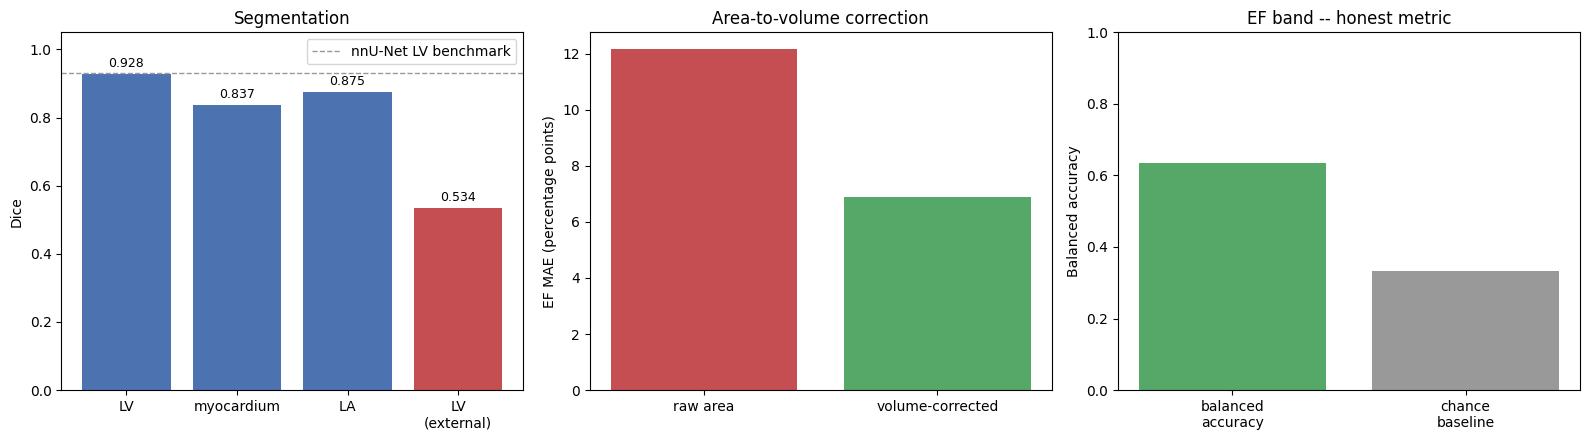

In [15]:
print('=' * 68)
print('CARDIAC AGENT -- FINAL')
print('=' * 68)
print('Model     : EfficientNet-B0 U-Net, CAMUS-trained, no fine-tuning')
print(f'Parameters: {n_params:,}')
print('Role      : reports findings + confidence. Urgency is decided by the')
print('            Clinical Reasoning Agent, not here.')
print()
print('Segmentation -- CAMUS validation (in-distribution):')
for k, v in final_dice.items():
    print(f'  {k:<12} Dice = {v:.3f}')
print('  Benchmark (nnU-Net on CAMUS): LV=0.93, myocardium=0.86, LA=0.89')
print()
print('Segmentation -- archive.zip (external, never trained on):')
print(f'  LV           Dice = {dice_archive:.3f}   fragmentation = {frag_rate:.1f}%')
print('  No patient/clip metadata -- generalization indicator, not a clinical claim.')
print()
print('Finding -- EF band (the agent output, volume-corrected):')
print(f'  MAE                = {ef_mae:.1f} pp   (raw area EF: {raw_mae:.1f} pp)')
print(f'  Correlation        = {ef_corr:.3f}')
print(f'  Balanced accuracy  = {ef_bal3:.1%}   (baseline {1/3:.1%})')
print(f'  Plain accuracy     = {ef_agree3:.1%}   (majority baseline {ef_base3:.1%}, misleading here)')
print(f'  severe<->normal    = {worst} of {cm.sum()} cases')
print(f'  Confidence ECE     = {ece:.3f}   (before calibration: {ece_raw:.3f})')
print()
print('Rejected after testing: augmentation upgrade, archive2 integration (2 ways),')
print('fine-tuning on archive.zip (2 ways). See the experiment log at the top.')
print('=' * 68)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

labels = list(final_dice.keys()) + ['LV\n(external)']
vals = [final_dice[k] for k in final_dice] + [dice_archive]
bars = axes[0].bar(labels, vals, color=['#4C72B0'] * 3 + ['#C44E52'])
for b_, v in zip(bars, vals):
    axes[0].text(b_.get_x() + b_.get_width() / 2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
axes[0].axhline(0.93, color='#999999', ls='--', lw=1, label='nnU-Net LV benchmark')
axes[0].set_ylabel('Dice'); axes[0].set_ylim(0, 1.05); axes[0].set_title('Segmentation'); axes[0].legend()

axes[1].bar(['raw area', 'volume-corrected'], [raw_mae, ef_mae], color=['#C44E52', '#55A868'])
axes[1].set_ylabel('EF MAE (percentage points)')
axes[1].set_title('Area-to-volume correction')

axes[2].bar(['balanced\naccuracy', 'chance\nbaseline'], [ef_bal3, 1 / 3], color=['#55A868', '#999999'])
axes[2].set_ylim(0, 1); axes[2].set_ylabel('Balanced accuracy')
axes[2].set_title('EF band -- honest metric')

plt.tight_layout(); plt.show()
